In [15]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable
import csv
import pandas as pd
print(pd.__version__)
print(np.__version__)

2.2.2
1.26.4


In [16]:
plt.rcParams['font.family'] = 'Times New Roman' 
plt.rcParams['mathtext.fontset'] = 'stix' 
plt.rcParams["font.size"] = 12
plt.rcParams['xtick.labelsize'] = 17
plt.rcParams['ytick.labelsize'] = 17 

plt.rcParams['xtick.direction'] = 'in' 
plt.rcParams['ytick.direction'] = 'in' 
plt.rcParams['axes.grid'] = True 

plt.rcParams["xtick.minor.visible"] = True  
plt.rcParams["ytick.minor.visible"] = True  
plt.rcParams['xtick.top'] = True  
plt.rcParams['ytick.right'] = True  

plt.rcParams["legend.fancybox"] = False 
plt.rcParams["legend.framealpha"] = 1
plt.rcParams["legend.edgecolor"] = 'black'
plt.rcParams["legend.markerscale"] = 5

In [17]:
df = pd.read_csv("fig_data/switch_resource_allocation_sweep.csv")

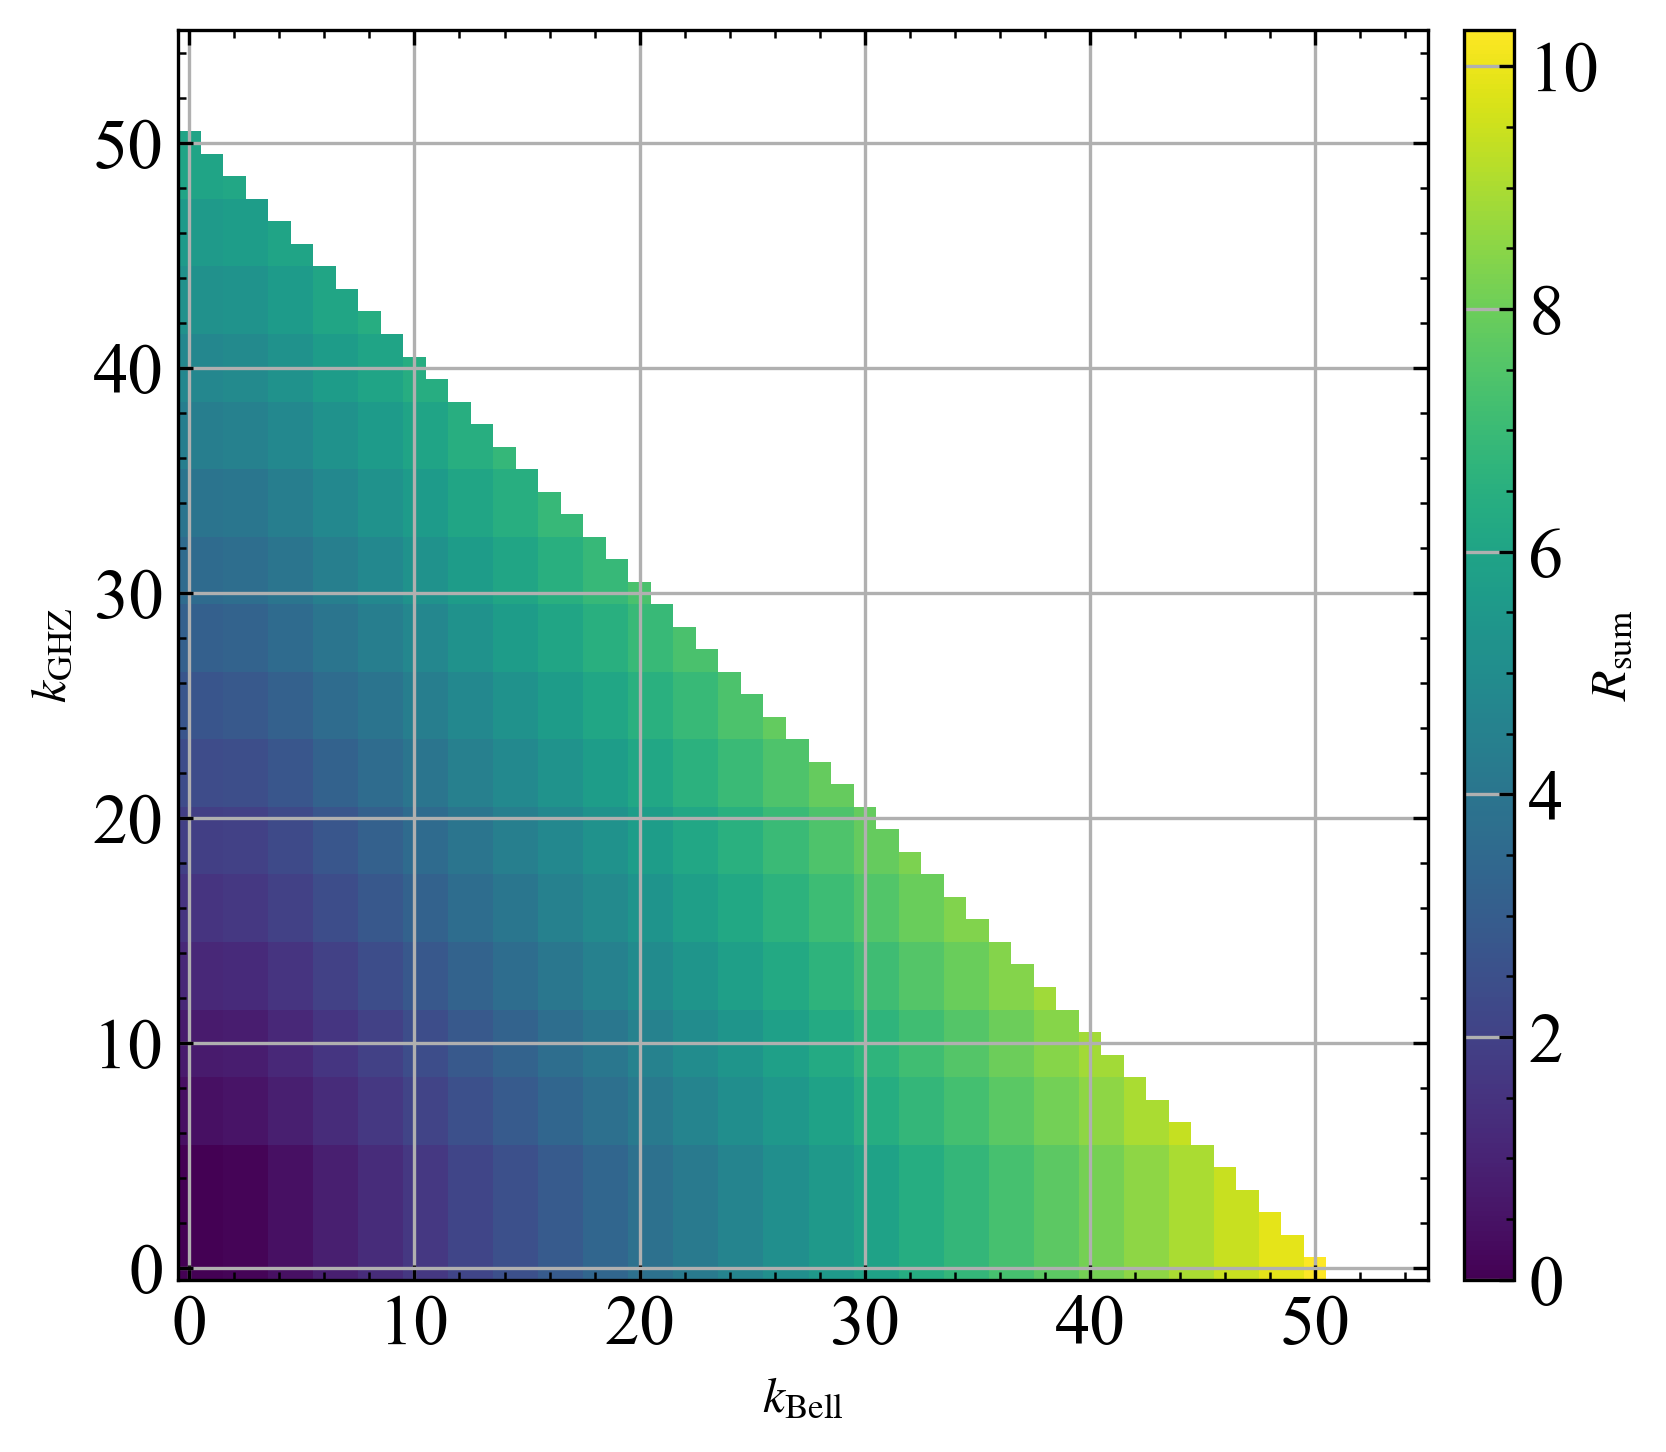

In [24]:
def main():
    value_col = "rateSum"
    kSWMax = int(df["kSW"].max())
    
    # Build a 2D grid: grid[kBell, kGHZ] = selected rate
    grid = np.full((kSWMax + 1, kSWMax + 1), np.nan, dtype=float)
    k_bell = df["kBell"].to_numpy(dtype=int)
    k_ghz = df["kGHZ"].to_numpy(dtype=int)
    values = df[value_col].to_numpy(dtype=float)
    grid[k_bell, k_ghz] = values
    grid[0, 0] = 0.0

    # Define cell boundaries so that integer coordinates
    # (kBell, kGHZ) = 0, 1, 2, ... appear at the centers of the cells
    x_edges = np.arange(kSWMax + 2) - 0.5
    y_edges = np.arange(kSWMax + 2) - 0.5
    X, Y = np.meshgrid(x_edges, y_edges)

    # Plot
    fig, ax = plt.subplots(figsize=(6, 5), dpi=300)
    mesh = ax.pcolormesh(X, Y, grid.T, shading="flat")
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.12)
    cbar = fig.colorbar(mesh, cax=cax)
    cbar.set_label(r"$R_{\mathrm{sum}}$", labelpad=-2)

    ax.set_xlim(-0.5, kSWMax + 5)
    ax.set_ylim(-0.5, kSWMax + 5)
    ax.set_aspect("equal")
    ax.set_xticks(np.arange(0, kSWMax + 5, 10))
    ax.set_yticks(np.arange(0, kSWMax + 5, 10))
    ax.set_xlabel(r"$k_{\mathrm{Bell}}$")
    ax.set_ylabel(r"$k_{\mathrm{GHZ}}$")

    fig.tight_layout()
    fig.savefig(f"QCNC_PLOT1.png", bbox_inches="tight", pad_inches=0.05)
    plt.show()

if __name__ == "__main__":
    main()